In [1]:
!pip install -U vnstock

In [30]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [7]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 7.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.1.1
    Uninstalling pip-25.1.1:
      Successfully uninstalled pip-25.1.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
from vnstock import Listing, Quote, Company, Finance, Trading

In [24]:
listing = Listing()
listing.all_symbols()

,symbol,organ_name
0,YTC,Công ty Cổ phần Xuất nhập khẩu Y tế Thành phố ...
1,YEG,Công ty Cổ phần Tập đoàn Yeah1
2,YBM,Công ty Cổ phần Khoáng sản Công nghiệp Yên Bái
3,YBC,Công ty Cổ phần Xi măng và Khoáng sản Yên Bái
4,XPH,Công ty Cổ phần Xà phòng Hà Nội
...,...,...
1712,AAS,Công ty Cổ phần Chứng khoán SmartInvest
1713,AAM,Công ty Cổ Phần Thủy Sản MeKong
1714,AAH,Công ty Cổ phần Hợp Nhất
1715,AAA,Công ty Cổ phần Nhựa An Phát Xanh


In [30]:
import time
from vnstock import Listing, Vnstock
import os

SAVE_FOLDER = "data_stock"
os.makedirs(SAVE_FOLDER, exist_ok=True)

# ===== 1. Lấy danh sách mã =====
listing = Listing(source="VCI")  # chỉ nhận VCI hoặc MSN
symbols_df = listing.all_symbols()
tickers = symbols_df["symbol"].dropna().unique().tolist()

print(f"Tổng số mã: {len(tickers)}")

# ===== 2. Lấy dữ liệu lịch sử cho từng mã =====
for i, symbol in enumerate(tickers):
    try:
        stock = Vnstock().stock(symbol, "VCI")  # chỉ VCI/MSN
        df = stock.quote.history(start="2024-01-01", end="2025-08-01")
        df.to_csv(f"{SAVE_FOLDER}/{symbol}.csv", index=False)
        print(f"✅ Lưu xong {symbol} ({i+1}/{len(tickers)})")
        time.sleep(1.5)  # nghỉ 1.5 giây để tránh bị chặn
    except Exception as e:
        print(f"❌ Lỗi {symbol}: {e}")
        time.sleep(5)  # nếu lỗi thì nghỉ lâu hơn


Tổng số mã: 1717
✅ Lưu xong YTC (1/1717)
✅ Lưu xong YEG (2/1717)
✅ Lưu xong YBM (3/1717)
✅ Lưu xong YBC (4/1717)
✅ Lưu xong XPH (5/1717)
✅ Lưu xong XMP (6/1717)
✅ Lưu xong XMD (7/1717)
✅ Lưu xong XMC (8/1717)
✅ Lưu xong XLV (9/1717)
✅ Lưu xong XHC (10/1717)
✅ Lưu xong XDH (11/1717)
❌ Lỗi XDC: RetryError[<Future at 0x1d32baa6150 state=finished raised ValueError>]
✅ Lưu xong X77 (13/1717)
✅ Lưu xong X26 (14/1717)
✅ Lưu xong X20 (15/1717)
✅ Lưu xong WTC (16/1717)
✅ Lưu xong WSS (17/1717)
✅ Lưu xong WSB (18/1717)
✅ Lưu xong WCS (19/1717)
✅ Lưu xong VXT (20/1717)
✅ Lưu xong VXP (21/1717)
✅ Lưu xong VXB (22/1717)
✅ Lưu xong VWS (23/1717)
✅ Lưu xong VW3 (24/1717)
✅ Lưu xong VVS (25/1717)
✅ Lưu xong VVN (26/1717)
✅ Lưu xong VUA (27/1717)
✅ Lưu xong VTZ (28/1717)
✅ Lưu xong VTX (29/1717)
✅ Lưu xong VTV (30/1717)
✅ Lưu xong VTS (31/1717)
✅ Lưu xong VTR (32/1717)
✅ Lưu xong VTQ (33/1717)
✅ Lưu xong VTP (34/1717)
✅ Lưu xong VTO (35/1717)
✅ Lưu xong VTM (36/1717)
✅ Lưu xong VTL (37/1717)
✅ Lưu xong

In [3]:
import os
import pandas as pd

# Thư mục chứa 1000 file CSV
folder_path = r"E:\New folder\stock\data_stock"

# Lấy danh sách tất cả file CSV
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Danh sách để chứa dữ liệu từ từng file
dataframes = []

for i, file in enumerate(csv_files):
    file_path = os.path.join(folder_path, file)
    try:
        df = pd.read_csv(file_path)
        df["symbol"] = file.replace(".csv", "")  # thêm cột mã chứng khoán
        dataframes.append(df)
        print(f"Đã đọc {file} ({i+1}/{len(csv_files)})")
    except Exception as e:
        print(f"Lỗi khi đọc {file}: {e}")

# Gộp tất cả DataFrame lại
merged_df = pd.concat(dataframes, ignore_index=True)

# Lưu thành file Parquet
output_path = r"E:\New folder\stock\all_stocks.parquet"
merged_df.to_parquet(output_path, index=False)

print(f"✅ Đã gộp {len(csv_files)} file CSV thành {output_path}")
print(f"Tổng số dòng: {len(merged_df)}")


Đã đọc A32.csv (1/1620)
Đã đọc AAA.csv (2/1620)
Đã đọc AAH.csv (3/1620)
Đã đọc AAM.csv (4/1620)
Đã đọc AAS.csv (5/1620)
Đã đọc AAT.csv (6/1620)
Đã đọc AAV.csv (7/1620)
Đã đọc ABB.csv (8/1620)
Đã đọc ABC.csv (9/1620)
Đã đọc ABI.csv (10/1620)
Đã đọc ABR.csv (11/1620)
Đã đọc ABS.csv (12/1620)
Đã đọc ABT.csv (13/1620)
Đã đọc ABW.csv (14/1620)
Đã đọc ACB.csv (15/1620)
Đã đọc ACC.csv (16/1620)
Đã đọc ACE.csv (17/1620)
Đã đọc ACG.csv (18/1620)
Đã đọc ACL.csv (19/1620)
Đã đọc ACM.csv (20/1620)
Đã đọc ACS.csv (21/1620)
Đã đọc ACV.csv (22/1620)
Đã đọc ADC.csv (23/1620)
Đã đọc ADG.csv (24/1620)
Đã đọc ADP.csv (25/1620)
Đã đọc ADS.csv (26/1620)
Đã đọc AFX.csv (27/1620)
Đã đọc AG1.csv (28/1620)
Đã đọc AGF.csv (29/1620)
Đã đọc AGG.csv (30/1620)
Đã đọc AGM.csv (31/1620)
Đã đọc AGP.csv (32/1620)
Đã đọc AGR.csv (33/1620)
Đã đọc AGX.csv (34/1620)
Đã đọc AIC.csv (35/1620)
Đã đọc AIG.csv (36/1620)
Đã đọc ALT.csv (37/1620)
Đã đọc ALV.csv (38/1620)
Đã đọc AMC.csv (39/1620)
Đã đọc AMD.csv (40/1620)
Đã đọc AM

In [32]:
df = pd.read_parquet(r"E:\New folder\stock\all_stocks.parquet")
df.to_csv(r"E:\New folder\stock\all_stocks.csv", index=False)


In [33]:
df = pd.read_csv(r"E:\New folder\stock\all_stocks.csv")
df.head()

,time,open,high,low,close,volume,symbol
0,2024-01-02,27.22,27.22,27.22,27.22,415,A32
1,2024-01-03,26.61,26.61,26.08,26.34,1000,A32
2,2024-01-04,26.34,26.34,26.34,26.34,200,A32
3,2024-01-05,26.34,26.34,26.34,26.34,0,A32
4,2024-01-08,26.34,26.34,26.34,26.34,0,A32


In [34]:
df = df.rename(columns={
    "tradingDate":"date","TradingDate":"date","time":"date",
    "Open":"open","High":"high","Low":"low","Close":"close","Volume":"volume"
})
need = ["date","open","high","low","close","volume","symbol"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Thiếu cột: {missing}")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol","date"]).reset_index(drop=True)


In [7]:
print("---- EDA quick view ----")
print("Số dòng:", len(df), "| Số mã:", df["symbol"].nunique(),
      "| Khoảng thời gian:", df["date"].min().date(), "->", df["date"].max().date())
print(df[["open","high","low","close","volume"]].describe().round(3))

---- EDA quick view ----
Số dòng: 515294 | Số mã: 1620 | Khoảng thời gian: 2024-01-02 -> 2025-08-01
             open        high         low       close        volume
count  515294.000  515294.000  515294.000  515294.000  5.152940e+05
mean       20.794      21.015      20.568      20.806  6.328032e+05
std        28.606      28.911      28.324      28.636  3.121300e+06
min         0.040       0.040       0.040       0.040  0.000000e+00
25%         7.540       7.610       7.420       7.540  2.800000e+01
50%        13.000      13.090      12.800      13.000  4.100000e+03
75%        24.550      24.870      24.300      24.570  9.900000e+04
max       700.000     710.000     680.000     685.000  2.496817e+08


In [35]:
df.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
symbol    0
dtype: int64

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515294 entries, 0 to 515293
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    515294 non-null  datetime64[ns]
 1   open    515294 non-null  float64       
 2   high    515294 non-null  float64       
 3   low     515294 non-null  float64       
 4   close   515294 non-null  float64       
 5   volume  515294 non-null  int64         
 6   symbol  515294 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 27.5+ MB


In [37]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)


Series([], dtype: int64)


In [38]:
duplicates = df.duplicated().sum()
print("Số dòng trùng lặp:", duplicates)


Số dòng trùng lặp: 0


In [39]:
df.head()

,date,open,high,low,close,volume,symbol
0,2024-01-02,27.22,27.22,27.22,27.22,415,A32
1,2024-01-03,26.61,26.61,26.08,26.34,1000,A32
2,2024-01-04,26.34,26.34,26.34,26.34,200,A32
3,2024-01-05,26.34,26.34,26.34,26.34,0,A32
4,2024-01-08,26.34,26.34,26.34,26.34,0,A32


In [40]:
def add_features(df):
    df = df.sort_values(by=['symbol', 'time'])

    # MA5 và MA10
    df['ma_5'] = df.groupby('symbol')['close'].transform(lambda x: x.rolling(window=5).mean())
    df['ma_10'] = df.groupby('symbol')['close'].transform(lambda x: x.rolling(window=10).mean())

    # Volatility
    df['volatility'] = (df['high'] - df['low']) / df['low']

    # Momentum (so với 4 ngày trước)
    df['momentum'] = df.groupby('symbol')['close'].transform(lambda x: x / x.shift(4) - 1)

    return df

In [41]:
def train_model(df):
    df = add_features(df)
    df['target'] = df.groupby('symbol')['close'].shift(-1)

    df.replace([float('inf'), float('-inf')], pd.NA, inplace=True)
    df = df.dropna()

    features = ['ma_5', 'ma_10', 'volatility', 'momentum']
    X = df[features]
    y = df['target']

    split_index = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    #RandomForest
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    return df, model, X_train, X_test, y_train, y_test

In [42]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

    # Vẽ so sánh 200 mẫu đầu tiên
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.values[:200], label="Actual")
    plt.plot(y_pred[:200], label="Predicted")
    plt.title("So sánh giá đóng cửa ngày hôm sau (200 mẫu đầu - Test set)")
    plt.xlabel("Sample")
    plt.ylabel("Close Price")
    plt.legend()
    plt.show()

RMSE: 7.9494
MAE: 0.8463
R²: 0.9602


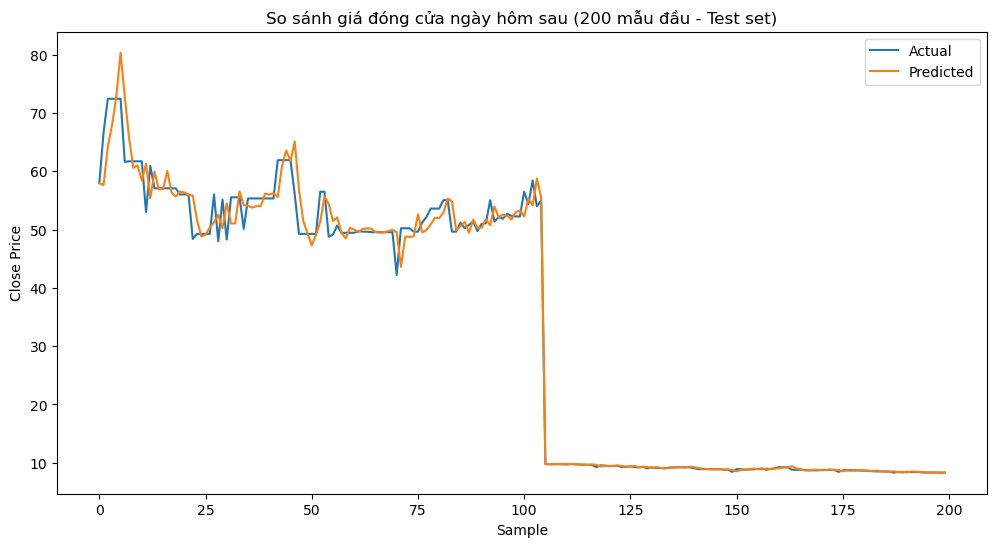

In [43]:
if __name__ == "__main__":
   
    df = pd.read_csv("all_stocks.csv")
    df['time'] = pd.to_datetime(df['time'])

    df, model, X_train, X_test, y_train, y_test = train_model(df)
    evaluate_model(model, X_test, y_test)

In [46]:
def add_features_single(df):
    df = df.sort_values(by=['time'])

    # MA5 và MA10
    df['ma_5'] = df['close'].rolling(window=5).mean()
    df['ma_10'] = df['close'].rolling(window=10).mean()

    # Độ biến động (Volatility) - độ lệch chuẩn 5 ngày
    df['volatility'] = df['close'].rolling(window=5).std()

    # Momentum (so sánh giá hiện tại với giá 5 ngày trước)
    df['momentum'] = df['close'] - df['close'].shift(5)

    return df


In [50]:
# Đọc dữ liệu
df_tcb = pd.read_csv(r"E:\New folder\stock\data_stock\TCB.csv")
df_tcb['time'] = pd.to_datetime(df_tcb['time'])

# Tạo features giống lúc train
df_tcb = add_features_single(df_tcb)

# Chọn cùng bộ features như khi train
features = ['ma_5', 'ma_10', 'volatility', 'momentum']
df_tcb = df_tcb.dropna(subset=features)  # bỏ dòng NaN do rolling

# Tách X (features) để dự đoán
X_tcb = df_tcb[features]

# Dự đoán giá đóng cửa ngày hôm sau
df_tcb['predicted_close'] = model.predict(X_tcb)

# Xem 5 kết quả mới nhất
print(df_tcb[['time', 'close', 'predicted_close']].tail())


          time  close  predicted_close
388 2025-07-28   35.6          37.8946
389 2025-07-29   33.9          27.5890
390 2025-07-30   34.5          28.2912
391 2025-07-31   34.0          29.1221
392 2025-08-01   34.1          29.1782


In [51]:
print(df_tcb.tail(1))

          time   open  high    low  close    volume   ma_5   ma_10  \
392 2025-08-01  34.15  34.7  34.05   34.1  20619700  34.42  34.815   

     volatility  momentum  predicted_close  
392    0.697854      -1.1          29.1782  
